# Assignment 3 - Factors, PCA, Copulas and EVT

__Authors: Team 20__<br>

Andreas: Copulas <br>
Hamza: Copulas <br>
Shubham: Factor Analysis <br>
Milan: EVT <br>
Siddharth: Setup and PCA 



## Setup - Data Loading and Cleaning

In [15]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import itertools

# --- Asset universe: 3 stocks | 2 bond ETFs | 2 indices | 3 commodity ETFs ---
assets = {
    # Stocks (large-cap, different sectors)
    "ASML":    "ASML.AS",    # Tech/semis
    "Shell":   "SHELL.AS",    # Energy
    "Walmart": "WMT",     # Consumer staples

    # Bonds (via ETFs — EUR sovereign + corp)
    "USTB":  "BND",    # iShares EUS Treasury Bond ETF
    "EUB": "SYBB.DE",    # State Street Euro Government Bond ETF

    # Indices
    "AEX":     "^AEX",       # Dutch equity index
    "SP500":   "^GSPC",      # US equity index

    # Commodities (via ETFs)
    "Gold":    "GLD",        # Gold
    "Oil":     "BNO",        # Brent crude
    "Iron":  "XME",       # Iron
}

tickers = list(assets.values())
names   = list(assets.keys())

raw = yf.download(tickers, start="2015-01-01", end="2024-12-31",
                  auto_adjust=True, progress=False)["Close"]

raw.columns = names   # rename to readable labels

# Drop any rows with more than 3 NaN (aligns all series to common trading days)
print(f"\nRaw NaN counts:\n{raw.isnull().sum().to_string()}")
prices_clean = raw.copy()
drop_mask = prices_clean.isnull().sum(axis=1) >= 3
prices_clean = prices_clean[~drop_mask]
print(f"\nRows dropped: {drop_mask.sum()}")

# Gap lengths after drop
print("\nNaN counts and max consecutive gap after drop:")
for col in prices_clean.columns:
    s = prices_clean[col]
    total = s.isnull().sum()
    max_gap = max((sum(1 for _ in g) for v, g in itertools.groupby(s.isnull()) if v), default=0)
    print(f"  {col:12s}  nans: {total:3d}  max_gap: {max_gap}")

prices_clean = prices_clean.dropna()

# Log returns
returns = np.log(prices_clean / prices_clean.shift(1)).dropna()

print(f"Shape: {returns.shape})")
returns.describe().T[["mean","std","min","max","count"]].round(4)


Raw NaN counts:
ASML       23
Shell      67
Walmart    67
USTB       67
EUB        23
AEX        41
SP500      67
Gold       67
Oil        23
Iron       67

Rows dropped: 90

NaN counts and max consecutive gap after drop:
  ASML          nans:   0  max_gap: 0
  Shell         nans:   0  max_gap: 0
  Walmart       nans:   0  max_gap: 0
  USTB          nans:   0  max_gap: 0
  EUB           nans:   0  max_gap: 0
  AEX           nans:  16  max_gap: 1
  SP500         nans:   0  max_gap: 0
  Gold          nans:   0  max_gap: 0
  Oil           nans:   0  max_gap: 0
  Iron          nans:   0  max_gap: 0
Shape: (2475, 10))


,mean,std,min,max,count
ASML,0.0009,0.0211,-0.1701,0.1170,2475.0
Shell,0.0001,0.0035,-0.0559,0.0413,2475.0
Walmart,0.0001,0.0238,-0.2473,0.1731,2475.0
USTB,0.0003,0.0090,-0.0552,0.0479,2475.0
EUB,0.0003,0.0188,-0.1922,0.2026,2475.0
AEX,0.0000,0.0034,-0.0178,0.0233,2475.0
SP500,0.0005,0.0134,-0.1208,0.1107,2475.0
Gold,0.0003,0.0212,-0.1607,0.1197,2475.0
Oil,0.0003,0.0111,-0.1138,0.0859,2475.0
Iron,0.0004,0.0113,-0.1277,0.0897,2475.0


__Correlation Heatmap__

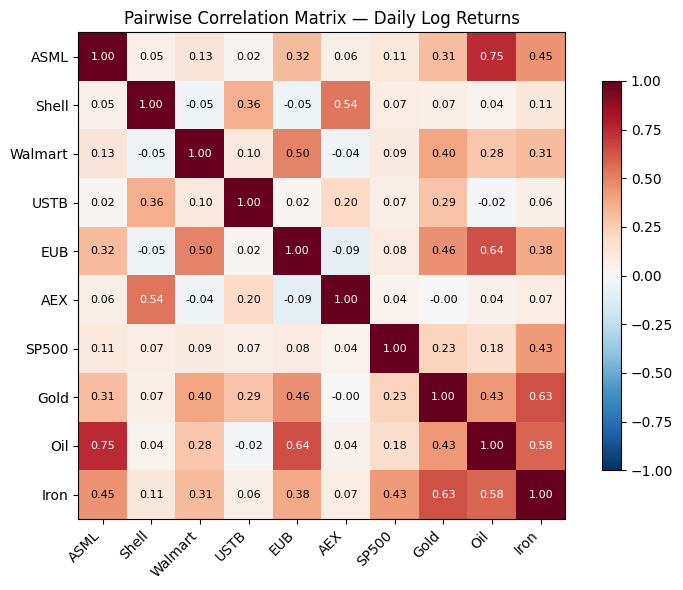

In [ ]:

corr = returns.corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set(xticks=range(len(corr)), xticklabels=corr.columns,
       yticks=range(len(corr)), yticklabels=corr.columns,
       title="Pairwise Correlation Matrix — Daily Log Returns")
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center",
                fontsize=8, color="white" if abs(corr.iloc[i,j]) > 0.5 else "black")
plt.colorbar(im, ax=ax, shrink=0.8)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

__Annualised Volatility__

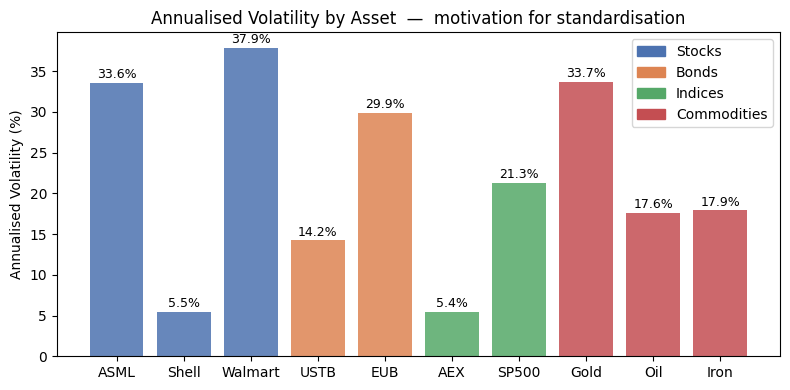

In [ ]:
ann_vol = returns.std() * np.sqrt(252)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#4C72B0"]*3 + ["#DD8452"]*2 + ["#55A868"]*2 + ["#C44E52"]*3
bars = ax.bar(ann_vol.index, ann_vol.values * 100, color=colors, alpha=0.85)
for bar, val in zip(bars, ann_vol.values * 100):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=9)
ax.set(ylabel="Annualised Volatility (%)",
       title="Annualised Volatility by Asset  —  motivation for standardisation")

# Asset class legend
from matplotlib.patches import Patch
legend = [Patch(color="#4C72B0", label="Stocks"),
          Patch(color="#DD8452", label="Bonds"),
          Patch(color="#55A868", label="Indices"),
          Patch(color="#C44E52", label="Commodities")]
ax.legend(handles=legend, loc="upper right")
plt.tight_layout()
plt.show()

__Covariance vs Correlation__

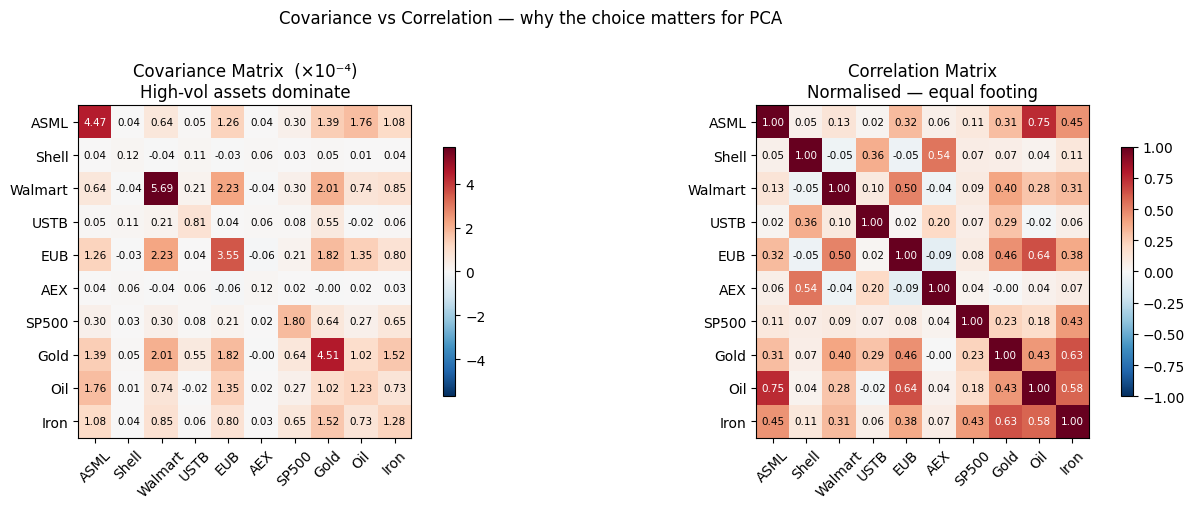

In [ ]:
cov  = returns.cov()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, mat, title, fmt in zip(
    axes,
    [cov * 1e4, corr],
    ["Covariance Matrix  (×10⁻⁴)\nHigh-vol assets dominate",
     "Correlation Matrix\nNormalised — equal footing"],
    [".2f", ".2f"]
):
    im = ax.imshow(mat.values, cmap="RdBu_r",
                   vmin=-mat.abs().max().max(), vmax=mat.abs().max().max())
    ax.set(xticks=range(len(mat)), xticklabels=mat.columns,
           yticks=range(len(mat)), yticklabels=mat.columns, title=title)
    for i in range(len(mat)):
        for j in range(len(mat)):
            ax.text(j, i, f"{mat.iloc[i,j]:{fmt}}", ha="center", va="center",
                    fontsize=7.5, color="white" if abs(mat.iloc[i,j]/mat.values.max()) > 0.5 else "black")
    ax.tick_params(axis="x", rotation=45)
    plt.colorbar(im, ax=ax, shrink=0.75)

plt.suptitle("Covariance vs Correlation — why the choice matters for PCA", y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

__Cumulative Returns__

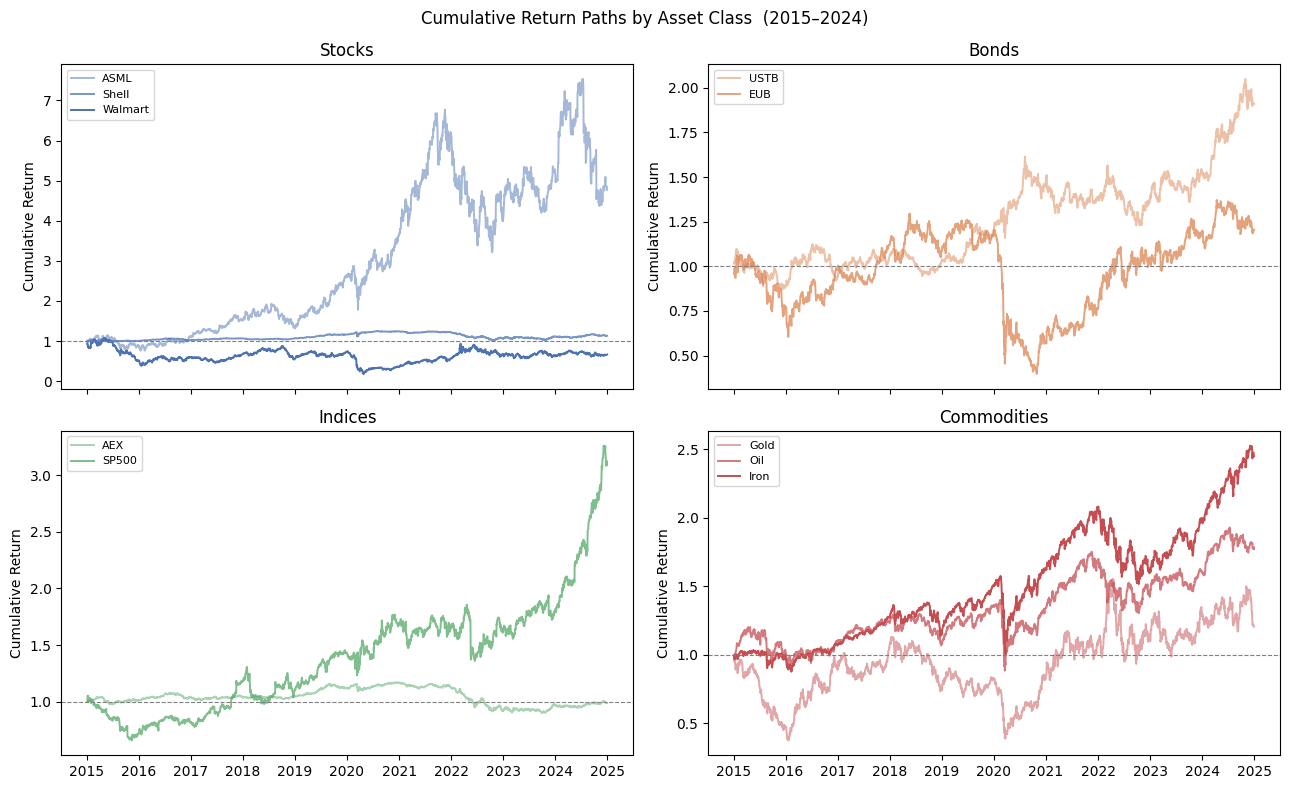

In [ ]:
cum_returns = (1 + returns).cumprod()

asset_classes = {
    "Stocks":      ["ASML", "Shell", "Walmart"],
    "Bonds":       ["USTB", "EUB"],
    "Indices":     ["AEX", "SP500"],
    "Commodities": ["Gold", "Oil", "Iron"],
}
colors_map = {"Stocks": "#4C72B0", "Bonds": "#DD8452",
              "Indices": "#55A868", "Commodities": "#C44E52"}

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
for ax, (cls, members) in zip(axes.flat, asset_classes.items()):
    for asset in members:
        ax.plot(cum_returns.index, cum_returns[asset],
                label=asset, color=colors_map[cls],
                alpha=0.5 + 0.25 * members.index(asset),
                linewidth=1.4)
    ax.set(title=cls, ylabel="Cumulative Return")
    ax.legend(fontsize=8)
    ax.axhline(1, color="gray", linestyle="--", linewidth=0.8)

plt.suptitle("Cumulative Return Paths by Asset Class  (2015–2024)", fontsize=12)
plt.tight_layout()
plt.show()

__Asset Correlations__

In [ ]:
print("  WITHIN-GROUP average correlations")
print("─" * 52)
for cls, members in asset_classes.items():
    if len(members) > 1:
        pairs = [(i, j) for i in members for j in members if i < j]
        avg_corr = np.mean([corr.loc[i, j] for i, j in pairs])
        print(f"  {cls:<14}  avg ρ = {avg_corr:.3f}")

print()
print("  CROSS-GROUP average correlations")
print("─" * 52)
class_list = list(asset_classes.keys())
for i in range(len(class_list)):
    for j in range(i+1, len(class_list)):
        g1, g2 = class_list[i], class_list[j]
        m1, m2 = asset_classes[g1], asset_classes[g2]
        avg_cross = np.mean([corr.loc[a, b] for a in m1 for b in m2])
        print(f"  {g1:<12} × {g2:<12}  avg ρ = {avg_cross:.3f}")

  WITHIN-GROUP average correlations
────────────────────────────────────────────────────
  Stocks          avg ρ = 0.045
  Bonds           avg ρ = 0.022
  Indices         avg ρ = 0.035
  Commodities     avg ρ = 0.550

  CROSS-GROUP average correlations
────────────────────────────────────────────────────
  Stocks       × Bonds         avg ρ = 0.207
  Stocks       × Indices       avg ρ = 0.138
  Stocks       × Commodities   avg ρ = 0.302
  Bonds        × Indices       avg ρ = 0.064
  Bonds        × Commodities   avg ρ = 0.300
  Indices      × Commodities   avg ρ = 0.157


## PCA

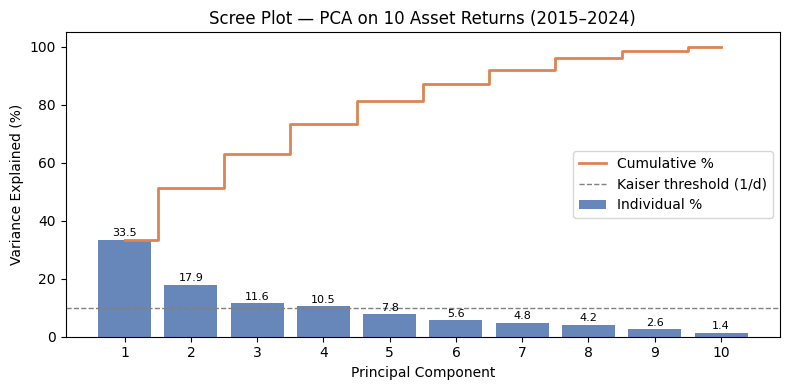

Kaiser's rule → 4 components (λ > 1)
90% variance  → 7 components


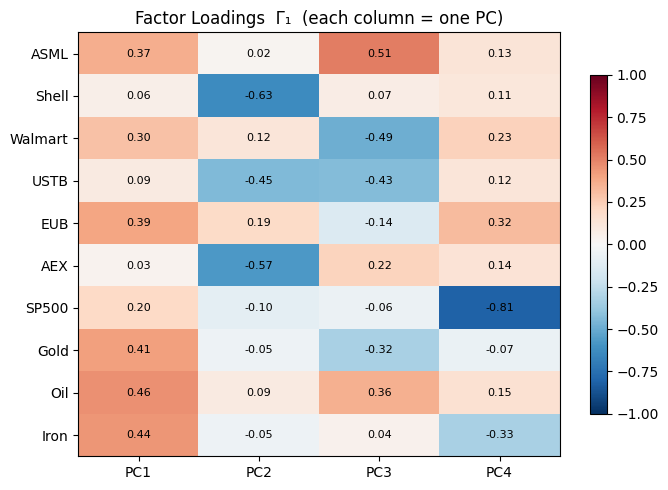


Variance explained per asset by 4 PCs:
ASML       0.415
Shell      0.419
Walmart    0.396
USTB       0.410
EUB        0.310
AEX        0.400
SP500      0.703
Gold       0.277
Oil        0.369
Iron       0.303


In [21]:
# ── Step 1: Demean (use standardised returns for PCA across mixed asset classes)
R = returns.dropna().copy()
X_tilde = (R - R.mean()) / R.std()          # standardise: mean 0, std 1 per asset

# ── Step 2: Covariance/correlation matrix  A = X̃'X̃ / n
n = len(X_tilde)
A = X_tilde.T @ X_tilde / n                 # this equals the correlation matrix here

# ── Step 3 & 4: Eigendecomposition, ordered largest → smallest
eigenvalues, eigenvectors = np.linalg.eig(A)
order = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[order].real
eigenvectors = eigenvectors[:, order].real   # columns are γ_i

# ── Step 5: Normalise eigenvectors to unit length (orthonormal)
eigenvectors = eigenvectors / np.linalg.norm(eigenvectors, axis=0)

# ── Step 6: How many factors? Scree plot + Kaiser's rule (λ > 1 for correlation PCA)
var_explained     = eigenvalues / eigenvalues.sum()
cumvar_explained  = np.cumsum(var_explained)
n_kaiser          = (eigenvalues > 1).sum()
n_90pct           = np.searchsorted(cumvar_explained, 0.90) + 1

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(range(1, len(eigenvalues) + 1), var_explained * 100, color="#4C72B0", alpha=0.85, label="Individual %")
ax.step(range(1, len(eigenvalues) + 1), cumvar_explained * 100, where="mid",
        color="#DD8452", linewidth=2, label="Cumulative %")
ax.axhline(100 / len(eigenvalues), color="gray", linestyle="--", linewidth=1, label="Kaiser threshold (1/d)")
for bar, val in zip(bars, var_explained * 100):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5, f"{val:.1f}",
            ha="center", va="bottom", fontsize=8)
ax.set(xlabel="Principal Component", ylabel="Variance Explained (%)",
       title="Scree Plot — PCA on 10 Asset Returns (2015–2024)",
       xticks=range(1, len(eigenvalues) + 1))
ax.legend(loc="center right")
plt.tight_layout()
plt.show()

print(f"Kaiser's rule → {n_kaiser} components (λ > 1)")
print(f"90% variance  → {n_90pct} components")

# ── Step 7 & 8: Choose p factors, build factor scores  F̂ = X̃ Γ₁
p = n_kaiser                                 # or override manually
Gamma_1 = eigenvectors[:, :p]                # d×p loading matrix
F_hat   = X_tilde.values @ Gamma_1          # n×p factor scores

factor_labels = [f"PC{i+1}" for i in range(p)]
F_hat = pd.DataFrame(F_hat, index=R.index, columns=factor_labels)

# ── Factor loadings heatmap (what does each PC "mean"?)
loadings = pd.DataFrame(Gamma_1, index=R.columns, columns=factor_labels)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(loadings.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set(xticks=range(p), xticklabels=factor_labels,
       yticks=range(len(R.columns)), yticklabels=R.columns,
       title="Factor Loadings  Γ₁  (each column = one PC)")
for i in range(len(R.columns)):
    for j in range(p):
        ax.text(j, i, f"{loadings.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

# ── Variance decomposition  Σ = Γ₁Γ₁' + Υ
Sigma_factor = Gamma_1 @ Gamma_1.T
Upsilon      = A - Sigma_factor              # idiosyncratic variance (diagonal)
R2_per_asset = pd.Series(np.diag(Sigma_factor) / np.diag(A),
                         index=R.columns, name="R² (factor-explained)")
print("\nVariance explained per asset by", p, "PCs:")
print(R2_per_asset.round(3).to_string())

## Factor Analysis


## Copulas

## EVT